# Nama: Ahmad Fauzan  
# NIM: 23051030014  

# Support Vector Machines: Exercise 1  

Author: Ahmad Fauzan  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahmaddfauzan/Exercise-SVM/blob/main/Exercise1.ipynb)

# A. SVM Classifier for MNIST Dataset

## Setup

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Machine Learning
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Konfigurasi plot
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['font.size'] = 12

# Folder untuk menyimpan hasil
os.makedirs("plots", exist_ok=True)

## 2 Load Dataset MNIST

In [22]:
# Load dataset MNIST
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

print("Shape data:", X.shape)
print("Shape label:", y.shape)

Shape data: (70000, 784)
Shape label: (70000,)


## 3. Visualisasi

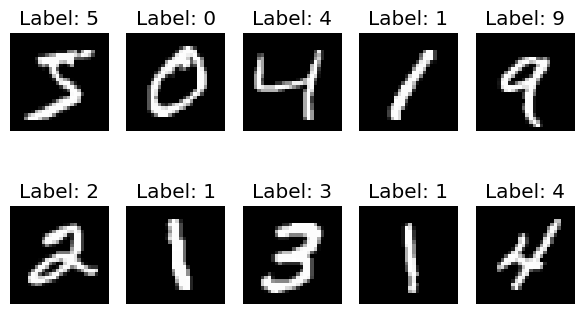

In [23]:
# Tampilkan beberapa contoh digit
fig, axes = plt.subplots(2,5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("plots/sample_digits.png")
plt.show()

## 4. Preprocessing & Scaling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# (Opsional tapi disarankan) Normalisasi pixel ke 0–1
X = X / 255.0

# Gunakan subset agar training lebih cepat
X_small, _, y_small, _ = train_test_split(
    X, y,
    train_size=12000,
    stratify=y,
    random_state=42
)

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9600, 784)
Test shape: (2400, 784)


In [25]:
scaler = StandardScaler()

# Fit hanya pada training data
X_train_scaled = scaler.fit_transform(X_train)

# Gunakan parameter yang sama untuk test
X_test_scaled = scaler.transform(X_test)

In [26]:
print("Mean (train):", np.mean(X_train_scaled))
print("Std (train):", np.std(X_train_scaled))

Mean (train): 2.343882835364037e-18
Std (train): 0.9354143466934856


## 5. Training SVM

In [28]:
from sklearn.svm import SVC

# Buat model SVM
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

# Training
svm_clf.fit(X_train_scaled, y_train)

SVC()

In [29]:
from sklearn.metrics import accuracy_score

# Prediksi
y_pred = svm_clf.predict(X_test_scaled)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", accuracy)

Baseline Accuracy: 0.9354166666666667


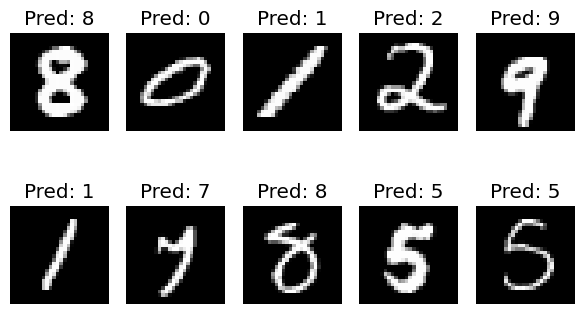

In [30]:
fig, axes = plt.subplots(2,5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("plots/baseline_predictions.png")
plt.show()

## 6. Fine Tuning SVM (GridSearch)

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 5, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 5, 10], 'gamma': ['scale', 0.01, 0.001]},
             verbose=2)

In [32]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 5, 'gamma': 0.001}
Best CV Score: 0.9403125


In [33]:
best_model = grid_search.best_estimator_

In [34]:
y_pred_tuned = best_model.predict(X_test_scaled)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Tuned Accuracy:", accuracy_tuned)

Tuned Accuracy: 0.9441666666666667


In [35]:
print("Baseline Accuracy :", accuracy)
print("Tuned Accuracy    :", accuracy_tuned)

Baseline Accuracy : 0.9354166666666667
Tuned Accuracy    : 0.9441666666666667


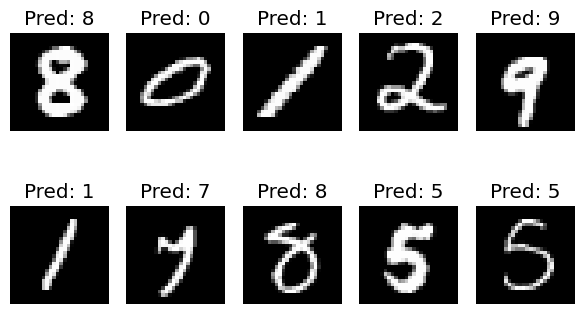

In [36]:
fig, axes = plt.subplots(2,5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"Pred: {y_pred_tuned[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("plots/tuned_predictions.png")
plt.show()

## 7. Confusion Matrix & Error Analysis

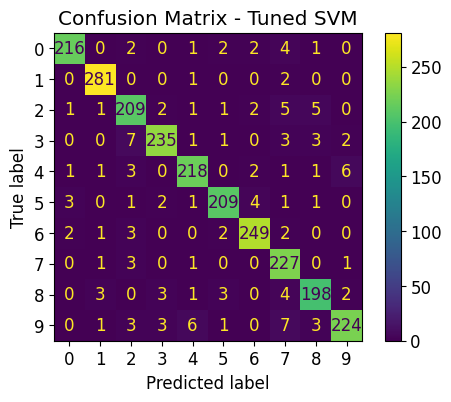

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Tuned SVM")

plt.savefig("plots/confusion_matrix.png")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       228
           1       0.97      0.99      0.98       284
           2       0.90      0.92      0.91       227
           3       0.96      0.93      0.95       252
           4       0.94      0.94      0.94       233
           5       0.95      0.94      0.95       222
           6       0.96      0.96      0.96       259
           7       0.89      0.97      0.93       233
           8       0.93      0.93      0.93       214
           9       0.95      0.90      0.93       248

    accuracy                           0.94      2400
   macro avg       0.94      0.94      0.94      2400
weighted avg       0.94      0.94      0.94      2400



In [39]:
# Cari indeks yang salah prediksi
errors = (y_pred_tuned != y_test)

X_errors = X_test[errors]
y_errors = y_test[errors]
y_pred_errors = y_pred_tuned[errors]

print("Jumlah error:", len(X_errors))

Jumlah error: 134


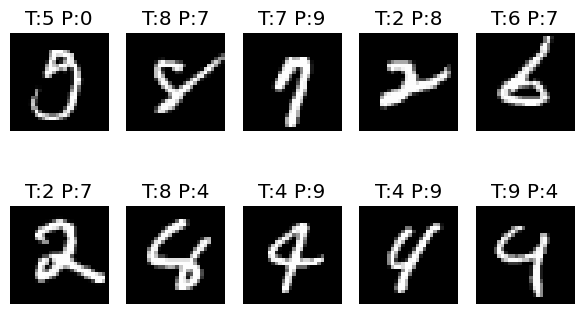

In [40]:
fig, axes = plt.subplots(2,5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_errors.iloc[i].values.reshape(28,28), cmap='gray')
    ax.set_title(f"T:{y_errors.iloc[i]} P:{y_pred_errors[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("plots/error_samples.png")
plt.show()

# B. SVM Regressor California Housing Dataset

## 1. Setup

In [41]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (20640, 8)
Shape y: (20640,)


## 2. Exploration

In [42]:
import pandas as pd

df = pd.DataFrame(X, columns=housing.feature_names)
df['target'] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Preprocessing

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Baseline SVR

In [44]:
from sklearn.svm import SVR

svr = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1
)

svr.fit(X_train_scaled, y_train)

SVR()

## 5. Evaluasi

In [45]:
from sklearn.metrics import mean_squared_error

y_pred = svr.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("RMSE:", rmse)

RMSE: 0.5974969813107396


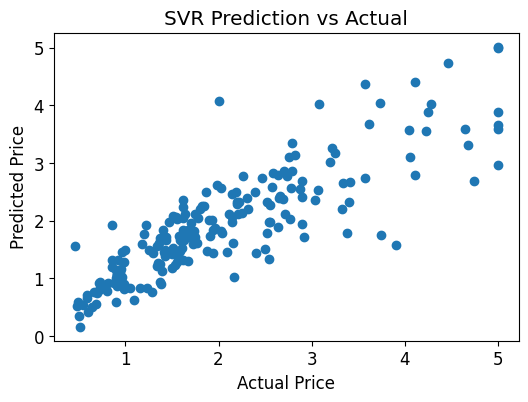

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test[:200], y_pred[:200])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("SVR Prediction vs Actual")

plt.savefig("plots/svr_prediction.png")
plt.show()

## 6. Fine Tuning

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10],
    'epsilon': [0.1, 0.2],
    'gamma': ['scale', 0.01]
}

grid_search = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

best_svr = grid_search.best_estimator_

print("Best Params:", grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'}


## 7. Evaluasi Model Terbaik

In [48]:
y_pred_best = best_svr.predict(X_test_scaled)

rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5

print("Baseline RMSE:", rmse)
print("Tuned RMSE   :", rmse_best)

Baseline RMSE: 0.5974969813107396
Tuned RMSE   : 0.5668083629534766


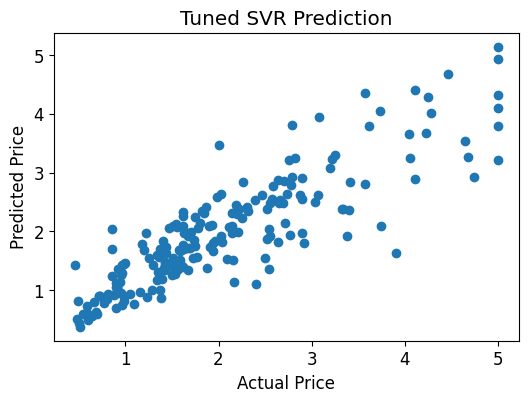

In [49]:
plt.scatter(y_test[:200], y_pred_best[:200])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Tuned SVR Prediction")

plt.savefig("plots/svr_tuned_prediction.png")
plt.show()

# C. Comparison Model

## 1. Training Model

In [51]:
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml # Added to re-fetch MNIST if X_small/y_small are not available, though in this case they are.

# --- Re-prepare MNIST data for classification comparison ---
# The X_small and y_small variables from the MNIST section are still available in the kernel state.
# If they weren't, we would need to re-fetch the MNIST dataset: mnist = fetch_openml('mnist_784', version=1); X_full = mnist.data / 255.0; y_full = mnist.target.astype(int)

# Re-split train-test for MNIST from the 'small' subset
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_small, y_small, # Using X_small and y_small from the original MNIST preprocessing
    test_size=0.2,
    random_state=42,
    stratify=y_small # Important for classification to maintain class distribution
)

# Re-scale MNIST data (re-initialize scaler to ensure it's fit only on MNIST data)
scaler_mnist = StandardScaler()
X_train_scaled_mnist = scaler_mnist.fit_transform(X_train_mnist)
X_test_scaled_mnist = scaler_mnist.transform(X_test_mnist)
# -----------------------------------------------------------


models = {
    "LinearSVC": LinearSVC(max_iter=10000, dual=False), # Added dual=False to avoid a future warning/error
    "SVC (Linear Kernel)": SVC(kernel='linear'),
    "SGDClassifier": SGDClassifier(max_iter=1000, tol=1e-3)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use the re-prepared MNIST data for classification
    model.fit(X_train_scaled_mnist, y_train_mnist)
    y_pred_model = model.predict(X_test_scaled_mnist)

    acc = accuracy_score(y_test_mnist, y_pred_model)
    results[name] = acc

    print(f"{name} Accuracy: {acc}")


Training LinearSVC...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC Accuracy: 0.86625

Training SVC (Linear Kernel)...
SVC (Linear Kernel) Accuracy: 0.9191666666666667

Training SGDClassifier...
SGDClassifier Accuracy: 0.9141666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [52]:
results

{'LinearSVC': 0.86625,
 'SVC (Linear Kernel)': 0.9191666666666667,
 'SGDClassifier': 0.9141666666666667}